# Encontro 4. O projeto, as fontes de dados e a dispersão

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA
**Docente:** Prof. Dr. Tadeu Gomes Teixeira

> **O que você vai fazer hoje, em três passos**
> 1. **Executar** as células de cima para baixo, uma de cada vez.
> 2. **Mudar um valor** no bloco de configuração, em um único lugar.
> 3. **Preencher a tabela dos seis critérios** para a fonte do seu projeto.
>
> Você não vai escrever código. Se alguma coisa não funcionar, **chame o professor**.

---

## Painel do encontro

A **Parte 2** de hoje fecha a estatística descritiva do Módulo I. Até agora você aprendeu
o centro de um conjunto de dados; hoje aprende que **uma medida só não descreve nada**.

| Item | Valor |
|---|---|
| **Fonte** | ANP — Agência Nacional do Petróleo, Gás Natural e Biocombustíveis |
| **Base** | SHPC — Série Histórica de Preços de Combustíveis |
| **O que é** | Preço de venda ao consumidor, **por posto**, por produto, por município |
| **Recorte** | Maranhão, ano de 2025 (12 arquivos mensais) |
| **Observações** | 10.641 posto-mês, dos quais **4.816 de gasolina comum** |
| **Unidade** | R$ por litro |
| **Confira em** | <https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis> |

**As colunas da tabela, depois da limpeza:**

| Coluna | O que é |
|---|---|
| `mes_arquivo` | O mês do arquivo de origem (1 a 12) |
| `municipio` | O município do posto |
| `revenda` | O nome do posto |
| `cnpj_da_revenda` | O CNPJ do posto — é a **chave** do registro |
| `produto` | Gasolina, gasolina aditivada ou etanol |
| `valor_venda` | O preço de venda, em R$ por litro |
| `bandeira` | A bandeira do posto |

> **Três coisas que fazem desta base a mais interessante até aqui.** Primeira: é
> **dado de registro**, uma linha por posto por mês, e não uma categoria já contada —
> é isso que permite calcular dispersão. Segunda: o valor vem no **padrão brasileiro**,
> com vírgula decimal, e sem `decimal=","` na leitura todos os valores viram `NaN` em
> silêncio. Terceira: a base traz o código `..` para "sem valor disponível", que é o
> **defeito de qualidade** do dia.

## Bloco de configuração

**Este é o único lugar do notebook onde se mexe em código.** Troque o valor abaixo,
execute esta célula de novo, e só então execute as células seguintes.

```python
# --- o que você pode mudar ---
PRODUTO = "GASOLINA"   # "GASOLINA", "GASOLINA ADITIVADA" ou "ETANOL"
```

In [1]:
PRODUTO = "GASOLINA"   # "GASOLINA", "GASOLINA ADITIVADA" ou "ETANOL"

print("Produto de hoje:", PRODUTO)

Produto de hoje: GASOLINA


## Utilitários da disciplina

`conferir` compara o seu resultado com o número que já estava resolvido no slide.
**Não precisa alterá-la.**

> **Regra de ouro do semestre:** *a IA explica, o código calcula, e você confere e
> escreve.*

In [2]:

# =====================================================================
#  UTILITARIOS DA DISCIPLINA - nao precisa alterar nada daqui para baixo
#  estas duas funcoes sao usadas pelas celulas do encontro. Se voce nao
#  sabe o que elas fazem, tudo bem: nao mexa. Voce so precisa executar.
# =====================================================================

def conferir(descricao, obtido, esperado, tolerancia=0.005, unidade="%"):
    """Confere o resultado calculado contra o valor ja resolvido no slide.

    Chame assim:  conferir("taxa de sobrevivencia do setor X", obtido, 0.412)

    O 'esperado' e o numero que ja estava escrito no slide, resolvido a mao
    pelo professor. Se aparecer [ok], o seu calculo esta certo. Se aparecer
    [X], confira a base, o filtro e a coluna que voce usou.
    """
    try:
        dif = abs(float(obtido) - float(esperado))
    except (TypeError, ValueError):
        print("  [X ] nao deu para comparar: obtido = %r" % (obtido,))
        return
    num = lambda v: ("%.*f%s" % (2, v, unidade)) if unidade else ("%.4f" % v)
    if dif <= tolerancia:
        print("  [ok] %-54s obtido %-9s esperado %s"
              % (descricao[:54], num(float(obtido)), num(float(esperado))))
    else:
        print("  [X ] %-54s obtido %-9s esperado %-9s dif %s"
              % (descricao[:54], num(float(obtido)), num(float(esperado)), num(dif)))


def cartao(df, coluna, nome_base="base"):
    """Imprime o contexto que voce precisa colar no assistente de IA.

    Chame assim:  cartao(dados, "porte")

    Copie a saida inteira e cole no pedido. E isso que impede a IA de
    inventar numero: ela so pode usar o que esta escrito no cartao.
    """
    print("=== CARTAO DE CONTEXTO (copie tudo daqui para o assistente) ===")
    print("base: %s" % nome_base)
    print("linhas x colunas: %d x %d" % df.shape)
    print("colunas e seu significado:")
    for c in df.columns:
        print("   - %s (%s)" % (c, df[c].dtype))
    if coluna in df.columns:
        print("valores unicos de '%s': %s"
              % (coluna, sorted(map(str, df[coluna].dropna().unique()))[:25]))
    print("=== fim do cartao ===")


print("Utilitarios carregados: conferir() e cartao() estao prontas para uso.")


Utilitarios carregados: conferir() e cartao() estao prontas para uso.


## Seção 1. Como se usa um notebook

Bloco de **texto** é explicação; bloco de **código** é instrução, e precisa ser executado
com **Shift + Enter**.

| Se isso aconteceu | Faça isso |
|---|---|
| O resultado não é o esperado | *Runtime → Run all*, de cima para baixo |
| Quero recomeçar | *Runtime → Restart runtime* |
| A célula B pediu um arquivo | *upload* do arquivo de `dados/` que o professor indicar |

## Seção 2. A base de hoje: preços de revenda da ANP

A primeira base do semestre que **não** vem do IBGE nem do Banco Central, e a primeira
no nível do **posto**. O notebook baixa os 12 meses de 2025 e recorta o Maranhão.

In [3]:
# ================= CÉLULA A: os 12 arquivos mensais da ANP =================
# Se esta célula falhar, peça ao professor para usar a CÉLULA B.

import io
import urllib.request

import pandas as pd

BASE_ANP = ("https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/"
            "arquivos/shpc/dsan/2025/precos-gasolina-etanol-%02d.csv")


def baixa_mes(mes):
    """Baixa um mês da série de preços da ANP e devolve só o Maranhão."""
    pedido = urllib.request.Request(BASE_ANP % mes,
                                    headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(pedido, timeout=180) as resposta:
        bruto = resposta.read()
    # duas armadilhas na mesma linha: o separador ';', a codificação com BOM e o
    # decimal com vírgula
    mes_df = pd.read_csv(io.BytesIO(bruto), sep=";", encoding="utf-8-sig",
                         decimal=",")
    # o arquivo da ANP não traz a coluna do mês: ela vem do nome do arquivo, então
    # é o próprio laço que a cria
    mes_df["mes"] = mes
    return mes_df[mes_df["Estado - Sigla"] == "MA"].copy()


quadros = []
for m in range(1, 13):
    quadros.append(baixa_mes(m))
    print(f"  mês {m:02d}: {len(quadros[-1]):4d} postos no MA")

anp = pd.concat(quadros, ignore_index=True)
anp = anp.rename(columns={"Municipio": "municipio", "Revenda": "revenda",
                          "CNPJ da Revenda": "cnpj", "Produto": "produto",
                          "Valor de Venda": "valor_venda", "Bandeira": "bandeira",
                          "mes": "mes"})
anp["mes"] = anp["mes"].astype(int)
anp["valor_venda"] = pd.to_numeric(anp["valor_venda"], errors="coerce")

print()
print(f"Base carregada: {len(anp)} posto-mês no Maranhão, 2025")
print(f"  municípios: {anp['municipio'].nunique()} | produtos: "
      f"{sorted(anp['produto'].unique())}")
print(f"  valores ausentes em valor_venda: {anp['valor_venda'].isna().sum()}")
anp.head(4)

  mês 01:  934 postos no MA


  mês 02:  855 postos no MA


  mês 03: 1037 postos no MA


  mês 04:  967 postos no MA


  mês 05:  915 postos no MA


...

  mês 09:  798 postos no MA


  mês 10:  880 postos no MA


  mês 11:  769 postos no MA


  mês 12:  965 postos no MA

Base carregada: 10641 posto-mês no Maranhão, 2025
  municípios: 11 | produtos: ['ETANOL', 'GASOLINA', 'GASOLINA ADITIVADA']
  valores ausentes em valor_venda: 0


,Regiao - Sigla,Estado - Sigla,municipio,revenda,cnpj,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,produto,Data da Coleta,valor_venda,Valor de Compra,Unidade de Medida,bandeira,mes
0,NE,MA,BARRA DO CORDA,MARCOS H. DA CUNHA,02.962.193/0002-78,RODOVIA BR 226,100,KM 63,CAJAZEIRA,65950-000,GASOLINA,02/01/2025,6.25,NaN,R$ / litro,BRANCA,1
1,NE,MA,BARRA DO CORDA,MARCOS H. DA CUNHA,02.962.193/0002-78,RODOVIA BR 226,100,KM 63,CAJAZEIRA,65950-000,GASOLINA ADITIVADA,02/01/2025,6.25,NaN,R$ / litro,BRANCA,1
2,NE,MA,BARRA DO CORDA,L. W. DE ALENCAR MENDES & CIA LTDA,02.311.352/0001-93,AVENIDA PEDRO AMORIM,60,NaN,ALTAMIRA,65950-000,GASOLINA,02/01/2025,6.25,NaN,R$ / litro,BRANCA,1
3,NE,MA,BARRA DO CORDA,L. W. DE ALENCAR MENDES & CIA LTDA,02.311.352/0001-93,AVENIDA PEDRO AMORIM,60,NaN,ALTAMIRA,65950-000,GASOLINA ADITIVADA,02/01/2025,6.26,NaN,R$ / litro,BRANCA,1


In [ ]:
# ================= CÉLULA B: CONTINGÊNCIA — leia antes =================
# NÃO EXECUTE AGORA. Execute apenas se o professor mandar, e só depois de fazer
# upload do arquivo dados/anp_precos_revenda_ma_2025.csv.

import pandas as pd

anp = pd.read_csv("anp_precos_revenda_ma_2025.csv")
anp = anp.rename(columns={"estado_-_sigla": "uf"})

print(f"Base carregada do arquivo local: {len(anp)} posto-mês no Maranhão, 2025")
anp.head(4)

## Parte 2 · Estatística: dispersão e forma da distribuição

**A pergunta do bloco.** Dois grupos podem ter a **mesma média** e serem completamente
diferentes. Como distinguir?

**As medidas de dispersão**

| Medida | O que é | Em corrente |
|---|---|---|
| **Amplitude** | maior − menor | o mais simples e o mais frágil |
| **Variância** | média dos quadrados dos desvios | por que o quadrado: senão os desvios se cancelam |
| **Desvio padrão** | a raiz da variância | devolve o número à unidade original |
| **Coeficiente de variação** | desvio ÷ média | permite comparar escalas diferentes |
| **IQR** | Q3 − Q1 | a dispersão do miolo, imune aos extremos |

**A fórmula do desvio padrão, com cada símbolo nomeado**

$$s = \sqrt{\frac{(x_1 - \bar{x})^2 + \dots + (x_n - \bar{x})^2}{n - 1}}$$

* $x_i$ é cada valor observado
* $\bar{x}$ é a média
* $n$ é a quantidade de valores
* $s$ é o desvio padrão

Em corrente: **veja quanto cada valor se afasta da média, eleve ao quadrado, tire a média
e depois a raiz.** A raiz é o que devolve o número à unidade original.

**Quando usar e quando não usar**

| | |
|---|---|
| **Use** | O desvio padrão para descrever a dispersão de uma variável; o **CV** quando for comparar variáveis **diferentes** |
| **Não use** | A amplitude como medida principal — ela depende de dois valores só. E nunca compare desvios de variáveis medidas em unidades diferentes |

In [4]:
# As medidas de dispersão, sobre o produto escolhido no CONFIG.
serie = anp[anp["produto"] == PRODUTO]["valor_venda"].dropna().reset_index(drop=True)

media = serie.mean()
mediana = serie.median()
desvio = serie.std()                       # no pandas, ddof=1 por padrão
cv = desvio / media * 100
q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
iqr = q3 - q1

print(f"{PRODUTO} no Maranhão, 2025 — {len(serie)} observações")
print(f"  média   = R$ {media:.2f}   (soma tudo e divide pelo número)")
print(f"  mediana = R$ {mediana:.2f}")
print(f"  desvio  = R$ {desvio:.2f}   (a oscilação típica em torno da média)")
print(f"  CV      = {cv:.2f}%   (o desvio como porcentagem da média)")
print(f"  amplitude = R$ {serie.max() - serie.min():.2f}   (máximo menos mínimo)")
print(f"  Q1 / Q3 / IQR = R$ {q1:.2f} / {q3:.2f} / {iqr:.2f}")
print()
print("A leitura completa, em uma frase:")
print(f"  \"o preço típico é R$ {media:.2f}, com oscilação típica de R$ {desvio:.2f} "
      f"({cv:.1f}% da média)\"")
print(f"  e metade dos postos entre R$ {q1:.2f} e R$ {q3:.2f}")

GASOLINA no Maranhão, 2025 — 4816 observações
  média   = R$ 6.13   (soma tudo e divide pelo número)
  mediana = R$ 6.08
  desvio  = R$ 0.42   (a oscilação típica em torno da média)
  CV      = 6.87%   (o desvio como porcentagem da média)
  amplitude = R$ 1.82   (máximo menos mínimo)
  Q1 / Q3 / IQR = R$ 5.79 / 6.45 / 0.66

A leitura completa, em uma frase:
  "o preço típico é R$ 6.13, com oscilação típica de R$ 0.42 (6.9% da média)"
  e metade dos postos entre R$ 5.79 e R$ 6.45


In [5]:
# AGORA A CONFERÊNCIA. Os números esperados já estavam escritos no slide.
conferir("média da gasolina no MA", media, 6.13, tolerancia=0.02, unidade=" R$")
conferir("desvio padrão", desvio, 0.42, tolerancia=0.02, unidade=" R$")
conferir("coeficiente de variação", cv, 6.87, tolerancia=0.05, unidade="%")
conferir("IQR", iqr, 0.66, tolerancia=0.02, unidade=" R$")

  [ok] média da gasolina no MA                                obtido 6.13 R$   esperado 6.13 R$
  [ok] desvio padrão                                          obtido 0.42 R$   esperado 0.42 R$
  [ok] coeficiente de variação                                obtido 6.87%     esperado 6.87%
  [ok] IQR                                                    obtido 0.66 R$   esperado 0.66 R$


### Por que o IQR é mais estável que a amplitude

Olhe os dois números: a **amplitude é R$ 1,82** e o **IQR é R$ 0,66**. A amplitude é
quase o triplo. Ela depende de dois valores apenas — o posto mais barato e o mais caro —
e basta um deles mudar para o número inteiro mudar. O IQR olha o miolo, onde estão metade
dos postos, e por isso não se abala com um extremo.

### O CV permite comparar o que o desvio não permite

O desvio acompanha a média: variável de média alta tende a ter desvio alto, sem que seja
mais dispersa. É por isso que comparar desvios de variáveis diferentes é erro. O
coeficiente de variação resolve — ele divide pelo próprio centro.

In [6]:
# O mesmo problema, dois mercados: o preço da gasolina em R$ e o IPCA em %.
# Os desvios não se comparam; os CV, sim.
gas = anp[anp["produto"] == "GASOLINA"]["valor_venda"].dropna()

import json
import urllib.request

pedido = urllib.request.Request(
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json",
    headers={"User-Agent": "Mozilla/5.0", "Accept": "application/json"})
with urllib.request.urlopen(pedido, timeout=90) as r:
    ipca = pd.DataFrame(json.loads(r.read()), columns=["data", "valor"])
ipca["valor"] = pd.to_numeric(ipca["valor"], errors="coerce")
ipca = ipca.dropna().tail(36)["valor"]

print("                 média      desvio      CV")
print("gasolina (R$/L)  %6.2f     %6.2f     %6.2f%%"
      % (gas.mean(), gas.std(), 100 * gas.std() / gas.mean()))
print("IPCA mensal (%%)  %6.2f     %6.2f     %6.2f%%"
      % (ipca.mean(), ipca.std(), 100 * ipca.std() / ipca.mean()))
print()
print("Os desvios não se comparam (R$ contra pontos percentuais).")
print("Os CV, sim: a variação mensal do IPCA é muito mais dispersa que o")
print("preço da gasolina no espaço.")

                 média      desvio      CV
gasolina (R$/L)    6.13       0.42       6.87%
IPCA mensal (%)    0.37       0.30      79.90%

Os desvios não se comparam (R$ contra pontos percentuais).
Os CV, sim: a variação mensal do IPCA é muito mais dispersa que o
preço da gasolina no espaço.


### A forma da distribuição

Agora a segunda metade: **quanto os quartis e o escore z dizem sobre a forma**.

$$z = \frac{x - \bar{x}}{s}$$

* $x$ é o valor observado
* $\bar{x}$ é a média e $s$ o desvio padrão
* $z$ diz **quantos desvios** o valor está acima ou abaixo da média

Em corrente: **tire a média do valor, e divida pelo desvio.** O resultado é
adimensional, e é por isso que permite comparar grandezas medidas em escalas
diferentes.

**Referência de leitura:** cerca de dois terços dos dados ficam entre $z=-1$ e $z=+1$, e
95% entre $-2$ e $+2$. Um valor com $z$ acima de 2 é incomum.

In [7]:
# Os cinco números, o escore z e a forma.
cinco = serie.quantile([0, 0.25, 0.5, 0.75, 1])
print("O esquema dos cinco números:")
print(f"  mínimo {cinco.iloc[0]:.2f} | Q1 {cinco.iloc[1]:.2f} | mediana "
      f"{cinco.iloc[2]:.2f} | Q3 {cinco.iloc[3]:.2f} | máximo {cinco.iloc[4]:.2f}")

z = (serie - media) / desvio
print()
print(f"O posto mais barato: R$ {serie.min():.2f} -> z = {z.min():+.2f}")
print(f"O posto mais caro:   R$ {serie.max():.2f} -> z = {z.max():+.2f}")

print()
print("A comparação com a regra 68-95-99,7 revela a forma:")
for k, esperado in [(1, 68.3), (2, 95.4), (3, 99.7)]:
    dentro = ((z > -k) & (z < k)).mean() * 100
    print(f"  |z| < {k}: observado {dentro:5.1f}%  |  a normal prevê {esperado:5.1f}%  "
          f"|  diferença {dentro - esperado:+.1f}")

print()
print(f"a média ({media:.2f}) é maior que a mediana ({mediana:.2f})? "
      f"{'sim' if media > mediana else 'não'}")
print(f"a assimetria calculada é {serie.skew():.2f}")
print("média acima da mediana e assimetria positiva = cauda à direita.")

O esquema dos cinco números:
  mínimo 5.37 | Q1 5.79 | mediana 6.08 | Q3 6.45 | máximo 7.19

O posto mais barato: R$ 5.37 -> z = -1.80
O posto mais caro:   R$ 7.19 -> z = +2.52

A comparação com a regra 68-95-99,7 revela a forma:
  |z| < 1: observado  59.3%  |  a normal prevê  68.3%  |  diferença -9.0
  |z| < 2: observado  96.6%  |  a normal prevê  95.4%  |  diferença +1.2
  |z| < 3: observado 100.0%  |  a normal prevê  99.7%  |  diferença +0.3

a média (6.13) é maior que a mediana (6.08)? sim
a assimetria calculada é 0.40
média acima da mediana e assimetria positiva = cauda à direita.


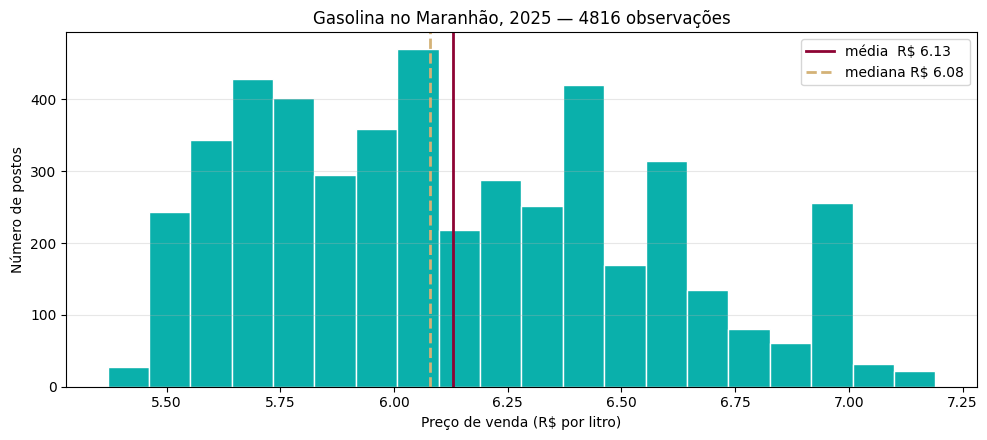

Repare que a média fica à direita da mediana: a cauda puxa a média.


In [8]:
# O histograma: a forma, desenhada. Vale mais que qualquer número.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(serie, bins=20, color="#0AB0AB", edgecolor="white")
ax.axvline(media, color="#8D0333", linewidth=2,
           label=f"média  R$ {media:.2f}")
ax.axvline(mediana, color="#D4B277", linewidth=2, linestyle="--",
           label=f"mediana R$ {mediana:.2f}")
ax.set_xlabel("Preço de venda (R$ por litro)")
ax.set_ylabel("Número de postos")
ax.set_title(f"{PRODUTO.title()} no Maranhão, 2025 — {len(serie)} observações")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Repare que a média fica à direita da mediana: a cauda puxa a média.")

In [9]:
# A distribuição de frequência com classes: a tabela que desenha o histograma.
# As classes são as do slide, de R$ 0,25 — e não as de largura automática, para que
# a tabela daqui e a da tela sejam a MESMA tabela.
CLASSES = [5.30, 5.55, 5.80, 6.05, 6.30, 6.55, 6.80, 7.05, 7.30]
classes = pd.cut(serie, bins=CLASSES, right=False)
tabela = (classes.value_counts().sort_index()
          .rename_axis("faixa").reset_index(name="postos"))
tabela["pct"] = (tabela["postos"] / len(serie) * 100).round(1)
tabela["pct_acumulado"] = tabela["pct"].cumsum().round(1)

# as quatro faixas largas, que são as que o slide mostra
largas = pd.cut(serie, bins=[5.30, 5.80, 6.30, 6.80, 7.30], right=False)
resumo = (largas.value_counts().sort_index()
          .rename_axis("faixa").reset_index(name="postos"))
resumo["pct"] = (resumo["postos"] / len(serie) * 100).round(1)

print(f"Distribuição de frequência, {len(serie)} postos em 8 classes de R$ 0,25:")
print(tabela.to_string(index=False))
print()
print("E as quatro faixas do slide:")
print(resumo.to_string(index=False))

conferir("postos entre R$ 5,30 e 5,80", float(resumo["postos"].iloc[0]), 1409.0,
         tolerancia=2, unidade="")
conferir("postos entre R$ 6,80 e 7,30", float(resumo["postos"].iloc[3]), 370.0,
         tolerancia=2, unidade="")

Distribuição de frequência, 4816 postos em 8 classes de R$ 0,25:
      faixa  postos  pct  pct_acumulado
[5.3, 5.55)     234  4.9            4.9
[5.55, 5.8)    1175 24.4           29.3
[5.8, 6.05)     833 17.3           46.6
[6.05, 6.3)     932 19.4           66.0
[6.3, 6.55)     712 14.8           80.8
[6.55, 6.8)     560 11.6           92.4
[6.8, 7.05)     317  6.6           99.0
[7.05, 7.3)      53  1.1          100.1

E as quatro faixas do slide:
     faixa  postos  pct
[5.3, 5.8)    1409 29.3
[5.8, 6.3)    1765 36.6
[6.3, 6.8)    1272 26.4
[6.8, 7.3)     370  7.7
  [ok] postos entre R$ 5,30 e 5,80                            obtido 1409.0000 esperado 1409.0000
  [ok] postos entre R$ 6,80 e 7,30                            obtido 370.0000  esperado 370.0000


**A frase que vai para o relatório**

> "Os 4.816 preços de gasolina comum coletados em postos do Maranhão em 2025 tiveram
> **média de R$ 6,13 e desvio padrão de R$ 0,42** (CV de 6,9%), com metade dos postos
> entre **R$ 5,79 e R$ 6,45**. A distribuição é assimétrica à direita
> (assimetria de 0,40): a média supera a mediana, porque há postos caros puxando a
> distribuição, e por isso o **preço típico** é descrito pela mediana (ANP, SHPC)."

**O que essa frase não diz.** Que a gasolina está cara. O desvio de R$ 0,42 é pequeno em
relação à média, o que indica **pouca variação entre postos** — mas isso não diz nada sobre
o nível do preço. Um mercado uniformemente caro tem desvio pequeno. São duas informações
diferentes, e a segunda exigiria comparar com outros estados.

## Seção 3. Usando o assistente

Três modos de uso, todos verificados. A regra: **a IA explica, o código calcula, e você
confere e escreve.**

### Modo 1 — Pergunta

Copie o cartão de contexto e cole no assistente. Sem o contexto, a IA inventa número.

In [10]:
cartao(anp[anp["produto"] == PRODUTO][["municipio", "produto", "valor_venda", "bandeira"]], "municipio", nome_base="ANP/SHPC — Maranhão, 2025")

=== CARTAO DE CONTEXTO (copie tudo daqui para o assistente) ===
base: ANP/SHPC — Maranhão, 2025
linhas x colunas: 4816 x 4
colunas e seu significado:
   - municipio (object)
   - produto (object)
   - valor_venda (float64)
   - bandeira (object)
valores unicos de 'municipio': ['ACAILANDIA', 'AMARANTE DO MARANHAO', 'BACABAL', 'BALSAS', 'BARRA DO CORDA', 'CODO', 'IMPERATRIZ', 'PINHEIRO', 'PRESIDENTE DUTRA', 'SAO JOSE DE RIBAMAR', 'SAO LUIS']
=== fim do cartao ===


### Modo 2 — Encomenda

Peça o código, cole na **célula cinza**. Só mude os parâmetros de consulta.

### Modo 3 — Ler um resultado errado

O professor preparou três leituras **erradas**, todas com números certos. O erro está no que
se concluiu delas. Diga qual é o erro, e o que deveria ter sido dito.

In [11]:
# ===================== CÉLULA CINZA — cole aqui o código do assistente =====================
# Sugestão de pedido: "compare a dispersão do preço entre os municípios do Maranhão,
# com média, desvio padrão e CV, ordenado pelo CV"
#
# Cole o código ABAIXO desta linha.

print("Cole o código do assistente ACIMA desta linha.")
print("Depois execute e confira com a função conferir.")
sua_analise = None

# =====================================================================================

Cole o código do assistente ACIMA desta linha.
Depois execute e confira com a função conferir.


In [12]:
# As três leituras erradas do professor.
print("ANÁLISE 1: 'o desvio padrão da gasolina é R$ 0,42 e o do IPCA é 0,30%, logo o")
print("           preço da gasolina varia mais que a inflação'")
print("           (as duas unidades são comparáveis? o desvio acompanha a média?)")
print()
print("ANÁLISE 2: 'o preço médio da gasolina é R$ 6,13, logo metade dos postos cobra")
print("           acima e metade abaixo'")
print("           (isso seria verdade em qual tipo de distribuição?)")
print()
print("ANÁLISE 3: 'a amplitude dos preços é R$ 1,82, logo o mercado é muito disperso'")
print("           (a amplitude olha quantos valores? o IQR diz outra coisa?)")

ANÁLISE 1: 'o desvio padrão da gasolina é R$ 0,42 e o do IPCA é 0,30%, logo o
           preço da gasolina varia mais que a inflação'
           (as duas unidades são comparáveis? o desvio acompanha a média?)

ANÁLISE 2: 'o preço médio da gasolina é R$ 6,13, logo metade dos postos cobra
           acima e metade abaixo'
           (isso seria verdade em qual tipo de distribuição?)

ANÁLISE 3: 'a amplitude dos preços é R$ 1,82, logo o mercado é muito disperso'
           (a amplitude olha quantos valores? o IQR diz outra coisa?)


**Gabarito:**

| Análise | O que há de errado |
|---|---|
| **1** | As **unidades não são comparáveis** — reais contra pontos percentuais — e o desvio acompanha a média. Dividindo pela média (o CV), a conclusão se **inverte**: o IPCA tem CV de 79,9% e a gasolina, 6,9% |
| **2** | Isso só vale em **distribuição simétrica**. Aqui a média (6,13) é maior que a mediana (6,08): **mais da metade** dos postos cobra abaixo da média, porque os caros puxam o número para cima |
| **3** | A amplitude usa **dois valores**, o mais barato e o mais caro. O IQR, que olha o miolo, é R$ 0,66 — menos de 40% da amplitude. O mercado é bem mais uniforme do que a amplitude sugere |

A análise 3 é a mais instrutiva: os dois números são verdadeiros, e as duas conclusões são
opostas. **Escolher a medida certa é o que decide a conclusão.**

## Seção 4. As três perguntas do dia

Responda **por escrito**, clicando duas vezes nesta célula e substituindo o texto entre as
linhas `---`.

**1. Escolha uma variável do seu trabalho ou da sua área e diga o que uma média esconderia sobre ela.**

_(pense no que a dispersão revelaria)_

---


**2. Você tem dois conjuntos com a mesma média. Que medida você pediria para distingui-los, e por quê?**

---


**3. Olhe o histograma da gasolina. Descreva a forma em uma frase, sem usar nenhum número.**

_(a forma é uma descrição; os números vêm depois)_

---


## Seção 5. A sua base, contra os seis critérios

Esta é a **primeira entrega parcial do projeto**. Preencha a tabela abaixo para a fonte que
você escolheu, e ela será conferida na AV1 do encontro 5.

| # | Critério | A sua fonte |
|---|---|---|
| 1 | **Periodicidade** — de quanto em quanto tempo é atualizada? | |
| 2 | **Granularidade** — a observação é a empresa, o município, a UF ou o país? | |
| 3 | **Cobertura** — quais territórios e quais anos existem de fato? | |
| 4 | **Metadado** — quem produz, com que metodologia? | |
| 5 | **Licença e citação** — o que posso publicar? Como cito? | |
| 6 | **Acesso** — há API, arquivo, ou é preciso digitar? | |

> **O critério que reprova mais projetos é a cobertura.** Muita base tem a variável que
> você quer, mas para outro período ou outro território. Descobrir isso agora custa uma
> tarde; descobrir depois custa o projeto.

**Escreva abaixo a frase de leitura da sua base: o que ela mostra, e o que ela não permite afirmar.**

---


## Antes de sair

- [ ] Executei o notebook inteiro de cima para baixo, sem erro
- [ ] Troquei `PRODUTO` para as três opções e conferi cada uma
- [ ] Preenchi a tabela dos seis critérios para a minha fonte
- [ ] Respondi as três perguntas por escrito
- [ ] Compartilhei o link do notebook

> Guarde este arquivo. Ele fecha o **guia de estatística descritiva** do Módulo I, que
> começou no encontro 1 e agora tem: frequência, níveis de mensuração, tendência central,
> dispersão e forma da distribuição.